# Imports

In [1]:
import os
import gc
import pickle
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import models, transforms

import torchvision.transforms as T

from transformers import (
    ViTModel,
    AutoModel,
    AutoImageProcessor,
    AutoModelForImageClassification
)

from captum.attr import (
    IntegratedGradients,
    Saliency,
    GradientShap,
    Occlusion
)

from quantus.metrics.faithfulness.faithfulness_correlation import FaithfulnessCorrelation
from quantus.metrics.complexity.complexity import Complexity
from quantus.metrics.complexity.sparseness import Sparseness
from quantus.metrics.robustness.local_lipschitz_estimate import LocalLipschitzEstimate

from scipy.stats import spearmanr

/home/aysel/tfe/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
from paths import (
    DATASETS_DIR,
    VISION_XAI_DIR,
    VISION_ARTIFACTS_DIR,
    VISION_EVAL_DIR,
    vision_xai_dir,
    vision_artifact_dir,
    vision_eval_dir,
    ensure_dirs
)

In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print("Using device:", device)

Using device: cuda


# Configuration

In [4]:
CURRENT_DATASET = "Flickr8k"
ensure_dirs()

df = pd.read_pickle(os.path.join(DATASETS_DIR, f"df_{CURRENT_DATASET}.pkl"))
IMAGE_PATHS = df["image_path"].tolist()
print(f"Loaded {len(IMAGE_PATHS)} images.")

# Limit for Pass 1 (Captum)
MAX_IMAGES = 50


Loaded 8091 images.


# Load Pretrained Models

In [6]:
def load_resnet50(device):
    weights = models.ResNet50_Weights.DEFAULT
    model = models.resnet50(weights=weights).to(device).eval()
    transform = weights.transforms()
    return model, transform

def load_mobilenet_v3(device):
    weights = models.MobileNet_V3_Large_Weights.DEFAULT
    model = models.mobilenet_v3_large(weights=weights).to(device).eval()
    transform = weights.transforms()
    return model, transform

class ViTWithHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = ViTModel.from_pretrained(
            "google/vit-base-patch16-224-in21k"
        )
        self.head = nn.Linear(self.backbone.config.hidden_size, 1000)

    def forward(self, x):
        out = self.backbone(pixel_values=x)
        cls = out.last_hidden_state[:, 0]
        return self.head(cls)


def load_vit(device):
    model = ViTWithHead().to(device).eval()

    transform = T.Compose([
        T.Resize((224, 224)),
        T.ToTensor(),
        T.Normalize([0.485, 0.456, 0.406],
                    [0.229, 0.224, 0.225])
    ])

    return model, transform

class CaptumWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        out = self.model(pixel_values=x)
        return out.logits


def load_pvt(device):
    processor = AutoImageProcessor.from_pretrained("Zetatech/pvt-tiny-224")
    base_model = AutoModelForImageClassification.from_pretrained(
        "Zetatech/pvt-tiny-224"
    )

    model = CaptumWrapper(base_model).to(device).eval()

    def transform(img):
        return processor(images=img, return_tensors="pt")["pixel_values"].squeeze(0)

    return model, transform

VISION_MODELS = {
    "PVT": load_pvt,
    "ViT": load_vit,
    "ResNet50": load_resnet50,
    "MobileNetV3": load_mobilenet_v3,
}

print("Loaded model definitions for:", list(VISION_MODELS.keys()))


Loaded model definitions for: ['PVT', 'ViT', 'ResNet50', 'MobileNetV3']


In [7]:
class ImageDataset(torch.utils.data.Dataset):
    """
    Loads images from disk and applies the model-specific transform.
    """

    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):

        path = self.image_paths[idx]

        # Load image safely
        try:
            img = Image.open(path).convert("RGB")
        except Exception:
            # If corrupted → return a blank image
            img = Image.new("RGB", (224, 224), (0, 0, 0))

        # Apply transform
        if self.transform:
            img = self.transform(img)

        return img


# Load Artifacts

In [8]:
def explain_ig(model, img, label):
    ig = IntegratedGradients(model)
    return ig.attribute(img.unsqueeze(0), target=label)

def explain_saliency(model, img, label):
    sal = Saliency(model)
    return sal.attribute(img.unsqueeze(0), target=label)

def explain_gradient_shap(model, img, label):
    gs = GradientShap(model)
    baseline = torch.zeros_like(img)
    return gs.attribute(
        img.unsqueeze(0),
        baselines=baseline.unsqueeze(0),
        target=label
    )

def explain_occlusion(model, img, label):
    occ = Occlusion(model)
    return occ.attribute(
        img.unsqueeze(0),
        target=label,
        sliding_window_shapes=(3, 15, 15),
        strides=(3, 8, 8)
    )


def to_numpy(attr):
    """Convert attribution tensor to numpy array."""
    return attr.detach().cpu().numpy().squeeze()


def normalize_attr(a):
    """Normalize attribution map to [0,1]."""
    a = np.abs(a)
    return (a - a.min()) / (a.max() - a.min() + 1e-8)


def flatten_attr(attr):
    """Flatten normalized attribution map."""
    return normalize_attr(to_numpy(attr)).flatten()


In [9]:
def save_tensor(path, tensor):
    """Utility to save a tensor safely."""
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save(tensor.detach().cpu(), path)

def save_list(path, list_of_tensors):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save(list_of_tensors, path)

class FeatureHook:
    """Registers a forward hook to capture CNN feature maps."""
    def __init__(self, module):
        self.features = None
        self.hook = module.register_forward_hook(self._hook_fn)

    def _hook_fn(self, module, inp, out):
        self.features = out.detach()

    def close(self):
        self.hook.remove()

def extract_and_save_artifacts(model_name, model, img, idx):
    """
    Extracts:
      - CLS embeddings (ViT, PVT)
      - Patch tokens (ViT, PVT)
      - Attention maps (ViT, PVT)
      - CNN feature maps (ResNet, MobileNet)
      - Logits (all models)
    Saves them under:
      TFE_Data/Model_Artifacts/vision/<dataset>/<model>/
    """

    artifact_root = vision_artifact_dir(CURRENT_DATASET, model_name)
    os.makedirs(artifact_root, exist_ok=True)

    # -----------------------------
    # CNN MODELS (ResNet, MobileNet)
    # -----------------------------
    if model_name in ["resnet50", "mobilenet_v3", "ResNet50", "MobileNetV3"]:
        # Hook last conv layer
        if model_name == "resnet50" or model_name == "ResNet50":
            hook = FeatureHook(model.layer4[-1])
        else:
            hook = FeatureHook(model.features[-1])

        with torch.no_grad():
            logits = model(img.unsqueeze(0))

        # Save logits
        save_tensor(f"{artifact_root}/Flickr8k/logits/{idx}.pt", logits)

        # Save CNN feature maps
        save_tensor(f"{artifact_root}/Flickr8k/features/{idx}.pt", hook.features)

        hook.close()
        return


    # -----------------------------
    # TRANSFORMER MODELS (ViT, PVT)
    # -----------------------------
    with torch.no_grad():

        if model_name == "pvt" or model_name == "PVT":
            # PVT: use .pvt and request attentions
            outputs = model.model.pvt(
                pixel_values=img.unsqueeze(0),
                output_hidden_states=True,
                output_attentions=True
            )

        else:  # ViT
            outputs = model.backbone(
                pixel_values=img.unsqueeze(0),
                output_hidden_states=True,
                output_attentions=True
            )

    # CLS embedding
    cls = outputs.last_hidden_state[:, 0, :]
    save_tensor(f"{artifact_root}/Flickr8k/cls/{idx}.pt", cls)

    # Patch tokens
    patches = outputs.last_hidden_state[:, 1:, :]
    save_tensor(f"{artifact_root}/Flickr8k/patch_tokens/{idx}.pt", patches)

    # Attention maps
    if outputs.attentions is not None and len(outputs.attentions) > 0:

        if model_name == "pvt" or model_name == "PVT":
            # PVT: attentions have different shapes → save list
            attn_list = [a.detach().cpu() for a in outputs.attentions]
            save_list(f"{artifact_root}/Flickr8k/attn/{idx}.pt", attn_list)

        else:
            # ViT: attentions uniform → stack OK
            attn = torch.stack([a.detach().cpu() for a in outputs.attentions])
            save_tensor(f"{artifact_root}/Flickr8k/attn/{idx}.pt", attn)

    # Logits
    with torch.no_grad():
        logits = model(img.unsqueeze(0))
    save_tensor(f"{artifact_root}/Flickr8k/logits/{idx}.pt", logits)


# Generate Explanations (Captum)

In [ ]:
all_captum_records = []   # For later Captum metrics

for model_name, loader_fn in VISION_MODELS.items():

    print(f"\n=== Running Pass 1 for model: {model_name} ===")

    model, transform = loader_fn(device)
    model.eval()

    dataset = ImageDataset(IMAGE_PATHS[:MAX_IMAGES], transform)
    loader = torch.utils.data.DataLoader(dataset, batch_size=1)

    xai_root = vision_xai_dir(CURRENT_DATASET, model_name)
    os.makedirs(xai_root, exist_ok=True)

    for idx, img in enumerate(tqdm(loader, desc=f"{model_name}")):

        img = img.squeeze(0).to(device)

        # Forward pass
        with torch.no_grad():
            logits = model(img.unsqueeze(0))
            label = logits.argmax(dim=1).item()

        ig_attr  = explain_ig(model, img, label)
        sal_attr = explain_saliency(model, img, label)
        gs_attr  = explain_gradient_shap(model, img, label)
        occ_attr = explain_occlusion(model, img, label)

        save_tensor(f"{xai_root}/IG_{idx}.pt", ig_attr)
        save_tensor(f"{xai_root}/Saliency_{idx}.pt", sal_attr)
        save_tensor(f"{xai_root}/GradShap_{idx}.pt", gs_attr)
        save_tensor(f"{xai_root}/Occlusion_{idx}.pt", occ_attr)

        save_tensor(f"{xai_root}/IG_only_{idx}.pt", ig_attr)

        extract_and_save_artifacts(model_name, model, img, idx)

        all_captum_records.append({
            "model": model_name,
            "idx": idx,
            "label": label,
            "IG": ig_attr.detach().cpu(),
            "Saliency": sal_attr.detach().cpu(),
            "GradShap": gs_attr.detach().cpu(),
            "Occlusion": occ_attr.detach().cpu(),
        })

print("\nPass 1 complete — Captum attributions and artifacts saved.")



=== Running Pass 1 for model: pvt ===


Loading weights:   0%|          | 0/177 [00:00<?, ?it/s]

pvt:   0%|          | 0/50 [00:00<?, ?it/s]


=== Running Pass 1 for model: vit ===


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

...


=== Running Pass 1 for model: resnet50 ===


resnet50:   0%|          | 0/50 [00:00<?, ?it/s]


=== Running Pass 1 for model: mobilenet_v3 ===


mobilenet_v3:   0%|          | 0/50 [00:00<?, ?it/s]


Pass 1 complete — Captum attributions and artifacts saved.


In [11]:
all_captum_records = []   # For later Captum metrics

for model_name, loader_fn in VISION_MODELS.items():

    print(f"\n=== Running Pass 1 for model: {model_name} ===")

    model, transform = loader_fn(device)
    model.eval()

    dataset = ImageDataset(IMAGE_PATHS, transform)
    loader = torch.utils.data.DataLoader(dataset, batch_size=1)

    xai_root = vision_xai_dir(CURRENT_DATASET, model_name)
    os.makedirs(xai_root, exist_ok=True)

    for idx, img in enumerate(tqdm(loader, desc=f"{model_name}")):

        img = img.squeeze(0).to(device)

        # Forward pass
        with torch.no_grad():
            logits = model(img.unsqueeze(0))
            label = logits.argmax(dim=1).item()

        ig_attr  = explain_ig(model, img, label)

        save_tensor(f"{xai_root}/Flickr8k/IG_{idx}.pt", ig_attr)

        extract_and_save_artifacts(model_name, model, img, idx)

        all_captum_records.append({
            "model": model_name,
            "idx": idx,
            "label": label,
            "IG": ig_attr.detach().cpu()
        })

print("\nPass 1 complete — Captum attributions and artifacts saved.")



=== Running Pass 1 for model: PVT ===


Loading weights:   0%|          | 0/177 [00:00<?, ?it/s]

PVT:   0%|          | 0/8091 [00:00<?, ?it/s]


=== Running Pass 1 for model: ViT ===


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

...


=== Running Pass 1 for model: ResNet50 ===


ResNet50:   0%|          | 0/8091 [00:00<?, ?it/s]


=== Running Pass 1 for model: MobileNetV3 ===


MobileNetV3:   0%|          | 0/8091 [00:00<?, ?it/s]


Pass 1 complete — Captum attributions and artifacts saved.


In [ ]:
with open(os.path.join(vision_xai_dir(CURRENT_DATASET, model_name), "captum_records_all.pkl"), "wb") as f:
    pickle.dump(all_captum_records, f)

all_captum_records[0]

In [106]:
with open(os.path.join(vision_xai_dir(CURRENT_DATASET, model_name), "captum_records.pkl"), "wb") as f:
    pickle.dump(all_captum_records, f)

all_captum_records[0]

{'model': 'pvt',
 'idx': 0,
 'label': 739,
 'IG': tensor([[[[ 8.8221e-03,  4.7056e-04,  1.5038e-03,  ..., -2.8641e-02,
             1.1816e-02, -4.7437e-02],
           [-1.2522e-03,  9.1775e-05,  6.1472e-05,  ..., -2.2318e-02,
            -5.6036e-02,  1.4470e-02],
           [ 9.4307e-03,  1.7963e-04, -1.2859e-06,  ..., -4.5182e-02,
            -1.9226e-02,  4.3421e-02],
           ...,
           [-5.5307e-03, -1.4934e-03,  2.7107e-03,  ..., -8.3361e-03,
             4.5395e-03, -7.8876e-03],
           [-9.6227e-03, -1.2807e-02,  2.0585e-02,  ..., -2.8101e-03,
             7.8351e-04, -1.0459e-02],
           [-1.1625e-02,  6.7119e-03,  2.6879e-03,  ..., -1.4942e-02,
             6.1390e-03, -3.1317e-03]],
 
          [[ 3.3799e-03, -4.8056e-03, -2.3270e-03,  ...,  7.6384e-02,
             3.9853e-02,  8.3926e-04],
           [ 7.2552e-03,  2.3511e-03,  3.1008e-03,  ...,  9.9290e-02,
            -1.4375e-03,  5.1551e-02],
           [ 5.8926e-04,  1.8265e-03,  8.7233e-03,  ...,  1.

In [ ]:
records_by_model = {}

for rec in all_captum_records:
    model = rec["model"]
    if model not in records_by_model:
        records_by_model[model] = []
    records_by_model[model].append(rec)

# Save each model's records separately
for model, recs in records_by_model.items():
    out_path = os.path.join(
        vision_xai_dir(CURRENT_DATASET, model),
        "captum_records.pkl"
    )
    with open(out_path, "wb") as f:
        pickle.dump(recs, f)
    print("Saved:", out_path, "(", len(recs), "records )")


Saved: TFE_Data/Attributions/Vision/Flickr8k/pvt/captum_records.pkl ( 50 records )
Saved: TFE_Data/Attributions/Vision/Flickr8k/vit/captum_records.pkl ( 50 records )
Saved: TFE_Data/Attributions/Vision/Flickr8k/resnet50/captum_records.pkl ( 50 records )
Saved: TFE_Data/Attributions/Vision/Flickr8k/mobilenet_v3/captum_records.pkl ( 50 records )


In [6]:
import torchvision.transforms as T

def compute_agreement(sample):
    ig  = flatten_attr(sample["IG"])
    sal = flatten_attr(sample["Saliency"])
    gs  = flatten_attr(sample["GradShap"])
    occ = flatten_attr(sample["Occlusion"])

    return {
        "ig_sal": spearmanr(ig, sal).correlation,
        "ig_gs":  spearmanr(ig, gs).correlation,
        "ig_occ": spearmanr(ig, occ).correlation,
        "sal_occ": spearmanr(sal, occ).correlation,
        "gs_occ": spearmanr(gs, occ).correlation,
    }

def mask_topk(img, attr, k=0.1):
    # Convert to numpy
    a = to_numpy(attr)  # could be (3,H,W) or (H,W)

    # If 3-channel → average across channels
    if a.ndim == 3:
        a = a.mean(axis=0)  # now H×W

    # Normalize
    a = (a - a.min()) / (a.max() - a.min() + 1e-8)

    # Compute mask
    threshold = np.quantile(a, 1 - k)
    mask = (a < threshold)  # H×W

    # Convert to tensor and expand to C×H×W
    mask_t = torch.tensor(mask, dtype=torch.bool, device=img.device)
    mask_t = mask_t.unsqueeze(0).repeat(img.shape[0], 1, 1)

    # Apply mask
    img_mod = img.clone()
    img_mod[mask_t] = 0
    return img_mod

def faithfulness_score(model_cpu, img_cpu, attr, label):
    with torch.no_grad():
        base = model_cpu(img_cpu.unsqueeze(0)).softmax(1)[0, label]

        masked = mask_topk(img_cpu, attr)
        new = model_cpu(masked.unsqueeze(0)).softmax(1)[0, label]

    return float(base - new)

def rank_corr_patch(model_cpu, img_cpu, label, attr, patch=16):

    # Convert attribution to H×W
    a = to_numpy(attr)
    if a.ndim == 3:
        a = a.mean(axis=0)

    H, W = a.shape
    impacts = []
    attrs_patched = []

    with torch.no_grad():
        base = model_cpu(img_cpu.unsqueeze(0)).softmax(1)[0, label].item()

        for i in range(0, H, patch):
            for j in range(0, W, patch):

                img_mod = img_cpu.clone()
                img_mod[:, i:i+patch, j:j+patch] = 0

                out = model_cpu(img_mod.unsqueeze(0)).softmax(1)[0, label].item()
                impacts.append(base - out)

                attrs_patched.append(a[i:i+patch, j:j+patch].mean())

    return float(spearmanr(attrs_patched, impacts).correlation)


def metric_entropy(attr):
    a = to_numpy(attr)
    if a.ndim == 3:
        a = a.mean(axis=0)
    a = np.abs(a)
    a = a / (a.sum() + 1e-8)
    return float(-np.sum(a * np.log(a + 1e-8)))


AUGS = [
    T.RandomRotation(5),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.RandomHorizontalFlip(p=1.0)
]

def metric_stability(model_cpu, img_cpu, label, attr_original):

    ig = IntegratedGradients(model_cpu)
    sims = []

    for aug in AUGS:
        img_aug = aug(img_cpu).unsqueeze(0)

        # Compute IG on augmented image
        attr_aug = ig.attribute(img_aug, target=label)

        # Convert both to numpy
        a1 = attr_original.detach().cpu().numpy().flatten()
        a2 = attr_aug.detach().cpu().numpy().flatten()

        # Cosine similarity
        sim = np.dot(a1, a2) / (np.linalg.norm(a1)*np.linalg.norm(a2) + 1e-8)
        sims.append(sim)

    return float(np.mean(sims))



In [ ]:
captum_metrics_by_model = {}

for model_name in VISION_MODELS.keys():

    print(f"\n=== Computing Captum metrics for {model_name} ===")

    # Load model
    model, transform = VISION_MODELS[model_name](device)
    model.eval()
    
    model_cpu = model.to("cpu").eval()
    img_cpu = img.to("cpu")

    # Filter records for this model
    records = [r for r in all_captum_records if r["model"] == model_name]

    model_metrics = []

    for rec in records:
        idx = rec["idx"]
        label = rec["label"]

        # Load image again (for faithfulness, stability, rank corr)
        img = transform(Image.open(IMAGE_PATHS[idx])).to(device)

        # Compute metrics
        agreement = compute_agreement(rec)
        faith = faithfulness_score(model_cpu, img_cpu, rec["IG"], label)
        rankc = rank_corr_patch(model_cpu, img_cpu, label, rec["IG"])
        ent = metric_entropy(rec["IG"])
        stab = metric_stability(model_cpu, img_cpu, label, rec["IG"])

        model_metrics.append({
            "idx": idx,
            "label": label,
            **agreement,
            "faithfulness": faith,
            "rank_corr": rankc,
            "entropy": ent,
            "stability": stab,
        })

    # Save metrics
    out_path = os.path.join(
        vision_xai_dir(CURRENT_DATASET, model_name),
        "captum_metrics.pkl"
    )
    with open(out_path, "wb") as f:
        pickle.dump(model_metrics, f)

    captum_metrics_by_model[model_name] = model_metrics

print("\nCaptum metrics saved for all models.")



=== Computing Captum metrics for pvt ===


Loading weights:   0%|          | 0/177 [00:00<?, ?it/s]


=== Computing Captum metrics for vit ===


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]


=== Computing Captum metrics for resnet50 ===

=== Computing Captum metrics for mobilenet_v3 ===

Captum metrics saved for all models.


# Quantus Metrics

In [ ]:
import quantus
from quantus import FaithfulnessCorrelation, Complexity, Sparseness

def reduce_attr_for_quantus(attr):
    a = attr.detach().cpu().numpy()
    a = np.squeeze(a)          # remove singleton dims
    if a.ndim == 3:
        a = a.mean(axis=0)     # → (H, W)
    return a

def load_ig(model_name, idx):
    path = os.path.join(
        vision_xai_dir(CURRENT_DATASET, model_name),
        f"IG_only_{idx}.pt"
    )
    return torch.load(path)

def evaluate_quantus(model, img_cpu, label, attr):
    model_cpu = model.to("cpu").eval()

    x_np = img_cpu.unsqueeze(0).detach().cpu().numpy()
    a_np = reduce_attr_for_quantus(attr)[np.newaxis, ...]
    y_np = np.array([label])

    metrics = [
        FaithfulnessCorrelation(disable_warnings=True),
        Complexity(disable_warnings=True),
        Sparseness(disable_warnings=True),
    ]

    results = {}
    for m in metrics:
        try:
            score = m(
                model=model_cpu,
                x_batch=x_np,
                a_batch=a_np,
                y_batch=y_np
            )
            results[m.__class__.__name__] = float(score[0])
        except Exception as e:
            print(f"[Quantus error] {m.__class__.__name__}: {e}")
            results[m.__class__.__name__] = np.nan

    return results




=== Running Quantus metrics for pvt ===


Loading weights:   0%|          | 0/177 [00:00<?, ?it/s]


=== Running Quantus metrics for vit ===


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]


=== Running Quantus metrics for resnet50 ===

=== Running Quantus metrics for mobilenet_v3 ===

Quantus metrics saved for all models.


In [ ]:
quantus_results_by_model = {}

for model_name in VISION_MODELS.keys():

    print(f"\n=== Running Quantus metrics for {model_name} ===")

    model_cpu, transform = VISION_MODELS[model_name]("cpu")
    model_cpu.eval()

    results = []

    for rec in [r for r in all_captum_records if r["model"] == model_name]:

        idx = rec["idx"]
        label = rec["label"]

        img_cpu = transform(Image.open(IMAGE_PATHS[idx])).cpu()
        ig = load_ig(model_name, idx)

        sample_metrics = evaluate_quantus(model_cpu, img_cpu, label, ig)
        sample_metrics["idx"] = idx
        sample_metrics["label"] = label

        results.append(sample_metrics)

    out_path = os.path.join(
        vision_xai_dir(CURRENT_DATASET, model_name),
        "quantus_metrics.pkl"
    )
    with open(out_path, "wb") as f:
        pickle.dump(results, f)

    quantus_results_by_model[model_name] = results

print("\nQuantus metrics saved for all models.")


In [ ]:
summary_by_model = {}

for model_name in VISION_MODELS.keys():

    print(f"\n=== Aggregating metrics for {model_name} ===")

    captum_path = os.path.join(
        vision_xai_dir(CURRENT_DATASET, model_name),
        "captum_metrics.pkl"
    )
    with open(captum_path, "rb") as f:
        captum_data = pickle.load(f)

    df_captum = pd.DataFrame(captum_data)

    quantus_path = os.path.join(
        vision_xai_dir(CURRENT_DATASET, model_name),
        "quantus_metrics.pkl"
    )
    with open(quantus_path, "rb") as f:
        quantus_data = pickle.load(f)

    df_quantus = pd.DataFrame(quantus_data)

    df = pd.merge(df_captum, df_quantus, on=["idx", "label"], how="inner")

    numeric_cols = df.select_dtypes(include=[np.number]).columns
    summary_mean = df[numeric_cols].mean().to_frame("mean")
    summary_std = df[numeric_cols].std().to_frame("std")

    summary = pd.concat([summary_mean, summary_std], axis=1)

    # Save summary
    out_path = os.path.join(
        vision_xai_dir(CURRENT_DATASET, model_name),
        "metric_summary.csv"
    )
    summary.to_csv(out_path)

    summary_by_model[model_name] = summary

print("\nSummary tables saved for all models.")



=== Aggregating metrics for pvt ===

=== Aggregating metrics for vit ===

=== Aggregating metrics for resnet50 ===

=== Aggregating metrics for mobilenet_v3 ===

Summary tables saved for all models.


In [50]:
def load_metric_comparison_table():

    rows = []

    for model_name in VISION_MODELS.keys():

        summary_path = os.path.join(
            vision_xai_dir(CURRENT_DATASET, model_name),
            "metric_summary.csv"
        )

        if not os.path.exists(summary_path):
            print(f"Missing summary for {model_name}")
            continue

        # Load summary table
        summary = pd.read_csv(
            summary_path,
            index_col=0
        )

        row = {
            "model": model_name
        }

        # -----------------------------------------
        # SAFE METRIC EXTRACTION
        # -----------------------------------------
        metric_mapping = {
            "FaithfulnessCorrelation": "faithfulness",
            "Complexity": "complexity",
            "Sparseness": "sparsity",
            "rank_corr": "rank_corr",
        }

        for raw_metric, final_name in metric_mapping.items():

            if raw_metric in summary.index:

                row[final_name] = summary.loc[
                    raw_metric,
                    "mean"
                ]

            else:

                row[final_name] = np.nan

        rows.append(row)

    df_final = pd.DataFrame(rows)

    return df_final

In [51]:
df_metrics = load_metric_comparison_table()

print(df_metrics)

          model  faithfulness  complexity  sparsity  rank_corr
0           pvt     -0.042926    9.989751  0.643774   0.004973
1           vit     -0.009543   10.152931  0.593959  -0.025140
2      resnet50     -0.026609   10.000115  0.644534   0.010911
3  mobilenet_v3     -0.020717   10.081718  0.619473   0.002161


In [54]:
METRIC_DIRECTION = {
    "faithfulness": "high",
    "complexity": "low",
    "sparsity": "low",
    "rank_corr": "high"
}

def normalize_metrics(df):

    df_norm = df.copy()
    for col in df.columns:

        if col == "model":
            continue

        values = df[col].astype(float)

        vmin = values.min()
        vmax = values.max()

        # avoid division by zero
        if vmax - vmin == 0:
            df_norm[col] = 0.0
            continue

        norm = (values - vmin) / (vmax - vmin)
        df_norm[col] = norm

    return df_norm

def normalize_metrics_with_direction(df):

    df_norm = df.copy()
    for col in df.columns:

        if col == "model":
            continue

        values = df[col].astype(float)

        vmin = values.min()
        vmax = values.max()

        if vmax - vmin == 0:
            df_norm[col] = 0.0
            continue

        norm = (values - vmin) / (vmax - vmin)

        # invert if lower is better
        if col in METRIC_DIRECTION and METRIC_DIRECTION[col] == "low":
            norm = 1 - norm

        df_norm[col] = norm

    return df_norm

def soft_normalize(df):

    df_norm = df.copy()

    for col in df.columns:

        if col == "model":
            continue

        x = df[col].astype(float)

        # flip sign if lower is better
        if METRIC_DIRECTION.get(col, "high") == "low":
            x = -x

        z = (x - x.mean()) / (x.std() + 1e-8)

        df_norm[col] = 1 / (1 + np.exp(-z))

    return df_norm

def rank_normalize(df):

    df_norm = df.copy()

    for col in df.columns:

        if col == "model":
            continue

        x = df[col].astype(float)

        # invert ranking if lower is better
        if METRIC_DIRECTION.get(col, "high") == "low":
            x = -x

        ranks = x.rank(method="average")

        df_norm[col] = ranks / ranks.max()

    return df_norm

In [56]:
df = load_metric_comparison_table()

df_norm = normalize_metrics_with_direction(df)
df_norm_softmax = soft_normalize(df)
df_norm_rank = rank_normalize(df)

#print(df_norm)

print(df_norm_softmax)

#print(df_norm_rank)

          model  faithfulness  complexity  sparsity  rank_corr
0           pvt      0.215583    0.704200  0.317722   0.603889
1           vit      0.751538    0.220124  0.787805   0.188391
2      resnet50      0.470208    0.675233  0.310897   0.688443
3  mobilenet_v3      0.575438    0.417175  0.561794   0.561181


In [59]:
def radar_chart_wide(df_norm, model_name):

    metrics = ["faithfulness", "complexity", "sparsity", "rank_corr"]

    row = df_norm[df_norm["model"] == model_name].iloc[0]
    values = row[metrics].values.astype(float)

    angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()

    values = np.concatenate((values, [values[0]]))
    angles += angles[:1]

    plt.figure(figsize=(6,6))
    ax = plt.subplot(111, polar=True)

    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(
        ["Faithfulness", "Complexity", "Sparsity", "Rank Corr"],
        fontsize=11
    )

    ax.set_title(
        f"Explainability Radar — {model_name.upper()}",
        fontsize=13,
        fontweight="bold",
        pad=20
    )

    plt.tight_layout()

    save_path = os.path.join(
        vision_xai_dir("Flickr8k", model_name),
        f"radar_{model_name.lower()}.png"
    )

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Saved: {save_path}")

In [123]:
def radar_subplot(df_norm, save_path=None):

    metrics = ["faithfulness", "complexity", "sparsity", "rank_corr"]

    models = df_norm["model"].unique()

    angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]

    fig, axes = plt.subplots(
        2, 2,
        subplot_kw=dict(polar=True),
        figsize=(12, 10)
    )

    axes = axes.flatten()

    for i, model in enumerate(models):

        row = df_norm[df_norm["model"] == model].iloc[0]
        values = row[metrics].values.astype(float)
        values = np.concatenate((values, [values[0]]))

        ax = axes[i]

        ax.plot(angles, values, linewidth=2)
        ax.fill(angles, values, alpha=0.25)
        
        if model == "resnet50": model = "ResNet50"
        if model == "mobilenet_v3": model = "MobileNetV3"
        if model == "vit": model = "ViT"
        if model == "pvt": model = "PVT"

        ax.set_title(model, fontsize=12)

        labels = ["Faithfulness", "Complexity", "Compactness", "Rank_Corr"]

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(labels, fontsize=9)

        for i, (label, angle) in enumerate(zip(ax.get_xticklabels(), angles[:-1])):

            angle_deg = np.degrees(angle)
            label.set_rotation(angle_deg)
            label.set_horizontalalignment("center")
            
            if labels[i] in ["Faithfulness", "Compactness"]:
                label.set_fontsize(9)
                label.set_x(label.get_position()[1] * 3) 
                ax.tick_params(axis='x', pad=22)

    plt.tight_layout()

    if save_path:
        os.makedirs(save_path, exist_ok=True)
        plt.savefig(
            os.path.join(save_path, "radar_subplot_all_models.png"),
            dpi=300
        )

    plt.show()

In [129]:
def radar_single_model(df_norm, model_name, save_path=None):

    metrics = ["faithfulness", "complexity", "sparsity", "rank_corr"]

    row = df_norm[df_norm["model"] == model_name].iloc[0]
    values = row[metrics].values.astype(float)

    # close the loop
    values = np.concatenate((values, [values[0]]))

    angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.25)

    pretty_name = {
        "resnet50": "ResNet50",
        "mobilenet_v3": "MobileNetV3",
        "vit": "ViT",
        "pvt": "PVT"
    }.get(model_name, model_name)

    ax.set_title(
        f"Explainability Radar — {pretty_name}",
        fontsize=13,
        pad=20
    )

    # -------------------------
    labels = ["Faithfulness", "Complexity", "Compactness", "Rank Corr"]

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=10)

    # optional readability tuning
    for label, angle in zip(ax.get_xticklabels(), angles[:-1]):

        angle_deg = np.degrees(angle)

        label.set_rotation(angle_deg)

        if 90 <= angle_deg <= 270:
            label.set_horizontalalignment("right")
        else:
            label.set_horizontalalignment("left")

    plt.tight_layout()

    if save_path:
        os.makedirs(save_path, exist_ok=True)

        plt.savefig(
            os.path.join(save_path, f"radar_{model_name}.png"),
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

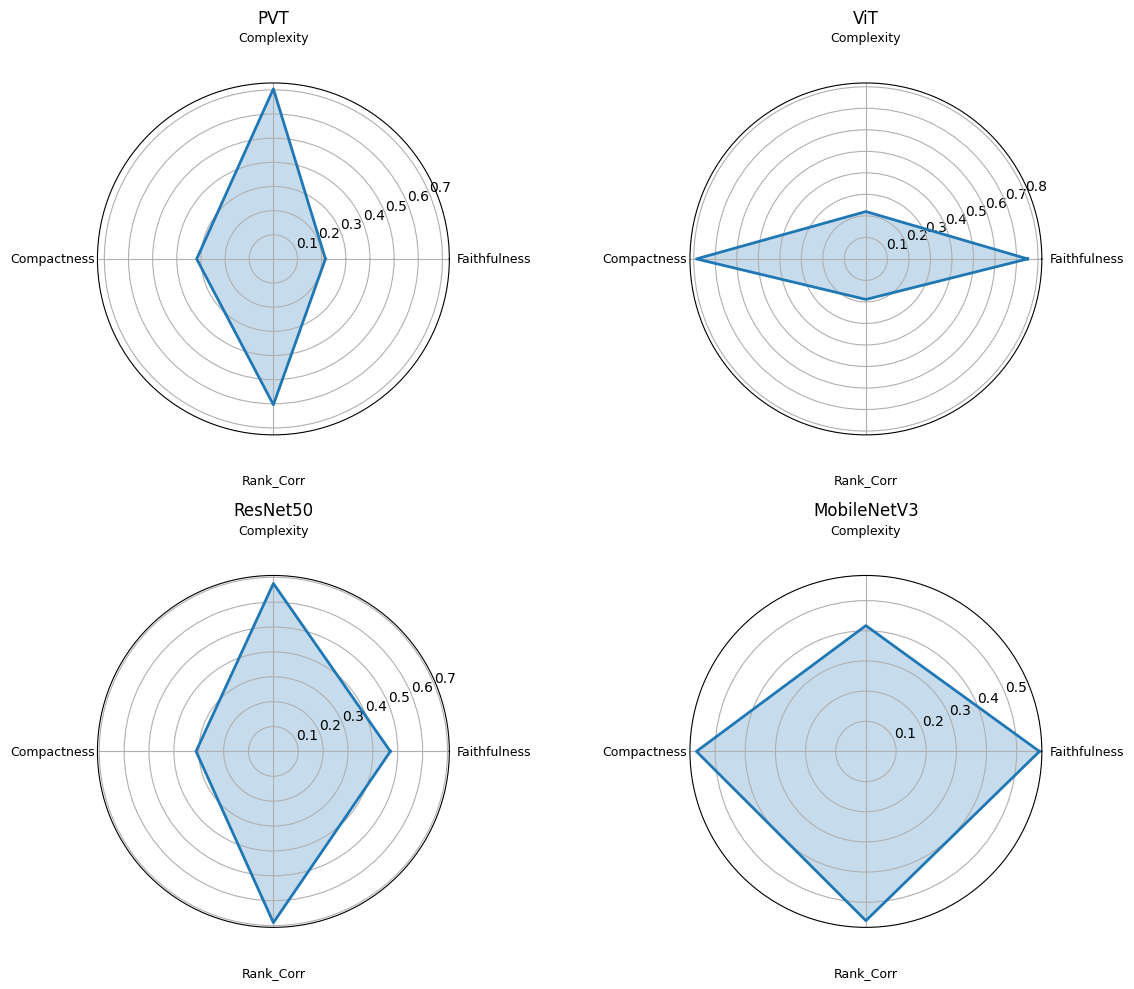

In [132]:
radar_subplot(df_norm_softmax, "streamlit_app/data/unimodal/metrics/XAI_Vision_Plots/Radar_Plots")

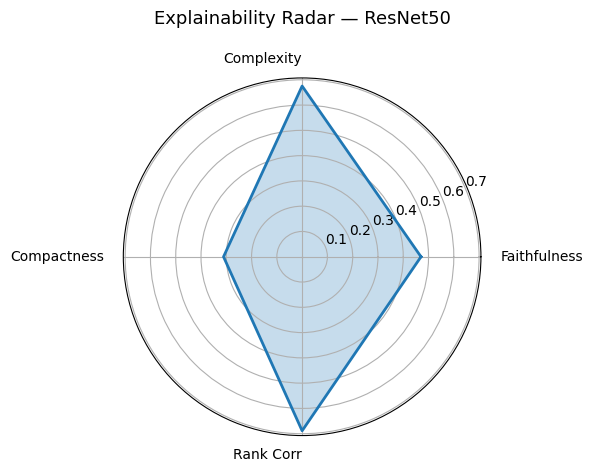

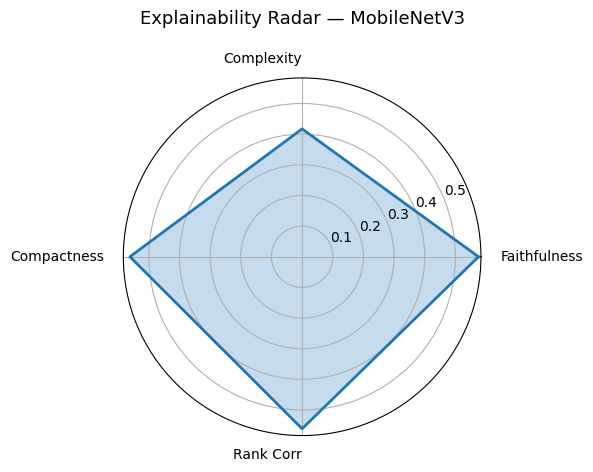

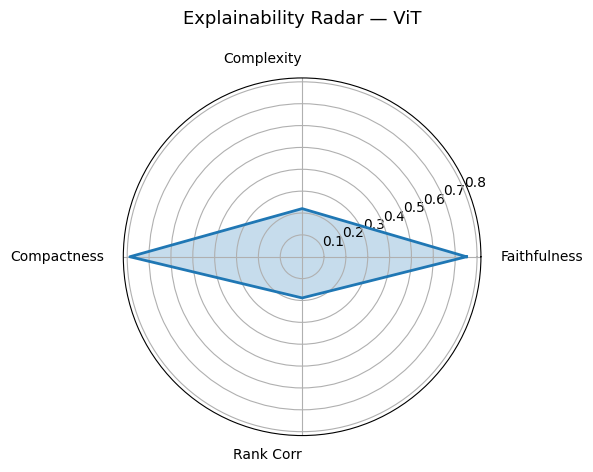

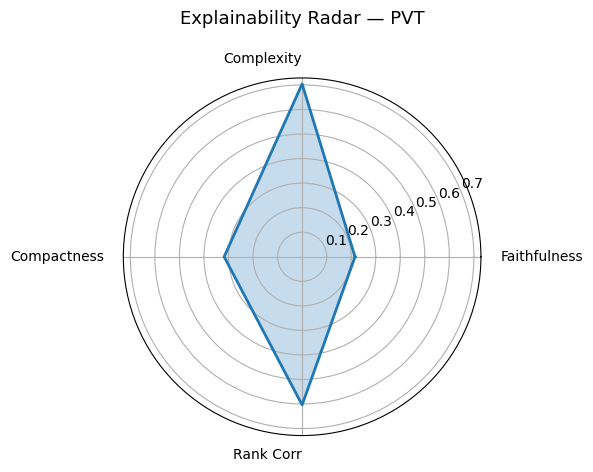

In [133]:
radar_single_model(df_norm_softmax, "resnet50", "streamlit_app/data/unimodal/metrics/XAI_Vision_Plots/Radar_Plots")
radar_single_model(df_norm_softmax, "mobilenet_v3", "streamlit_app/data/unimodal/metrics/XAI_Vision_Plots/Radar_Plots")
radar_single_model(df_norm_softmax, "vit", "streamlit_app/data/unimodal/metrics/XAI_Vision_Plots/Radar_Plots")
radar_single_model(df_norm_softmax, "pvt", "streamlit_app/data/unimodal/metrics/XAI_Vision_Plots/Radar_Plots")

# Cross-Method Agreement

In [15]:
def load_image_cpu(idx, transform):
    img = Image.open(IMAGE_PATHS[idx])
    return transform(img).cpu()

def attr_to_heatmap(attr):
    a = attr.detach().cpu().numpy()
    a = np.squeeze(a)
    if a.ndim == 3:
        a = a.mean(axis=0)
    a = np.abs(a)
    a = (a - a.min()) / (a.max() - a.min() + 1e-8)
    return a

def unnormalize(img):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    # If tensor → convert to numpy
    if hasattr(img, "numpy"):
        img = img.numpy().transpose(1, 2, 0)
    # If numpy → assume already HWC
    else:
        img = img

    img = img * std + mean
    img = np.clip(img, 0, 1)
    return img

def plot_attributions(model_name, idx):
    # Load model + transform
    model_cpu, transform = VISION_MODELS[model_name]("cpu")

    # Load image
    img = load_image_cpu(idx, transform)
    img_np = np.transpose(img.numpy(), (1, 2, 0))

    # Load Captum attributions
    captum_path = os.path.join(
        vision_xai_dir(CURRENT_DATASET, model_name),
        "captum_records.pkl"
    )
    with open(captum_path, "rb") as f:
        records = pickle.load(f)

    rec = [r for r in records if r["idx"] == idx][0]

    methods = ["IG", "Saliency", "GradShap", "Occlusion"]
    attrs = [rec[m] for m in methods]

    heatmaps = [attr_to_heatmap(a) for a in attrs]

    plt.figure(figsize=(12, 6))
    plt.subplot(2, 5, 1)
    plt.imshow(unnormalize(img_np))
    plt.title("Image")
    plt.axis("off")

    for i, (m, h) in enumerate(zip(methods, heatmaps)):
        plt.subplot(2, 5, i + 2)
        plt.imshow(h, cmap="Spectral")
        if m == "IG": m = "IntegratedGradients"
        plt.title(m)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

def plot_metric_distribution(model_name, metric_name):
    # Load Captum metrics
    captum_path = os.path.join(
        vision_xai_dir(CURRENT_DATASET, model_name),
        "captum_metrics.pkl"
    )
    with open(captum_path, "rb") as f:
        captum_data = pickle.load(f)

    df_captum = pd.DataFrame(captum_data)

    # Load Quantus metrics
    quantus_path = os.path.join(
        vision_xai_dir(CURRENT_DATASET, model_name),
        "quantus_metrics.pkl"
    )
    with open(quantus_path, "rb") as f:
        quantus_data = pickle.load(f)

    df_quantus = pd.DataFrame(quantus_data)

    df = pd.merge(df_captum, df_quantus, on=["idx", "label"], how="inner")

    if metric_name not in df.columns:
        print(f"Metric '{metric_name}' not found.")
        return

    values = df[metric_name].dropna()

    plt.figure(figsize=(6, 4))
    plt.hist(values, bins=20, color="steelblue", edgecolor="black")
    plt.title(f"{model_name} — {metric_name}")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

def compare_metric_across_models(metric_name):
    plt.figure(figsize=(8, 5))

    for model_name in VISION_MODELS.keys():
        quantus_path = os.path.join(
            vision_xai_dir(CURRENT_DATASET, model_name),
            "quantus_metrics.pkl"
        )
        captum_path = os.path.join(
            vision_xai_dir(CURRENT_DATASET, model_name),
            "captum_metrics.pkl"
        )

        with open(captum_path, "rb") as f:
            df_captum = pd.DataFrame(pickle.load(f))
        with open(quantus_path, "rb") as f:
            df_quantus = pd.DataFrame(pickle.load(f))

        df = pd.merge(df_captum, df_quantus, on=["idx", "label"], how="inner")

        if metric_name not in df.columns:
            continue

        vals = df[metric_name].dropna()
        plt.hist(vals, bins=20, alpha=0.4, label=model_name)

    plt.title(f"Comparison of {metric_name} across models")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

print("Visualization utilities loaded.")


Visualization utilities loaded.


In [26]:
def overlay_heatmap(img, heatmap, cmap="jet", alpha=0.45):

    # Convert colormap to RGB
    cmap_fn = plt.get_cmap(cmap)

    colored_hm = cmap_fn(heatmap)[..., :3]

    # Blend
    overlay = (
        (1 - alpha) * img +
        alpha * colored_hm
    )

    overlay = np.clip(overlay, 0, 1)

    return overlay

def plot_attributions_overlay(model_name, idx):
    # Load model + transform
    model_cpu, transform = VISION_MODELS[model_name]("cpu")

    # Load image
    img = load_image_cpu(idx, transform)
    img_np = np.transpose(img.numpy(), (1, 2, 0))

    # Load Captum attributions
    captum_path = os.path.join(
        vision_xai_dir(CURRENT_DATASET, model_name),
        "captum_records.pkl"
    )
    with open(captum_path, "rb") as f:
        records = pickle.load(f)

    rec = [r for r in records if r["idx"] == idx][0]

    methods = ["IG", "Saliency", "GradShap", "Occlusion"]
    attrs = [rec[m] for m in methods]

    heatmaps = [attr_to_heatmap(a) for a in attrs]

    plt.figure(figsize=(12, 6))
    plt.subplot(2, 5, 1)
    plt.imshow(unnormalize(img_np))
    plt.title("Image")
    plt.axis("off")

    for i, (m, h) in enumerate(zip(methods, heatmaps)):

        overlay = overlay_heatmap(
            unnormalize(img_np),
            h,
            cmap="jet",
            alpha=0.45
        )

        plt.subplot(2, 5, i + 2)

        plt.imshow(overlay)

        if m == "IG":
            m = "IntegratedGradients"

        plt.title(m)

        plt.axis("off")

    plt.tight_layout()
    plt.show()
    
def plot_attributions_and_overlay(model_name, idx):
    # Load model + transform
    model_cpu, transform = VISION_MODELS[model_name]("cpu")

    # Load image
    img = load_image_cpu(idx, transform)
    img_np = np.transpose(img.numpy(), (1, 2, 0))

    # Load Captum attributions
    captum_path = os.path.join(
        vision_xai_dir(CURRENT_DATASET, model_name),
        "captum_records.pkl"
    )
    with open(captum_path, "rb") as f:
        records = pickle.load(f)

    rec = [r for r in records if r["idx"] == idx][0]

    methods = ["IG", "Saliency", "GradShap", "Occlusion"]
    attrs = [rec[m] for m in methods]

    heatmaps = [attr_to_heatmap(a) for a in attrs]

    from matplotlib.gridspec import GridSpec

    img_vis = unnormalize(img_np)
    fig = plt.figure(figsize=(18, 8))
    gs = GridSpec(2,5, width_ratios=[1.8, 1, 1, 1, 1])


    ax_img = fig.add_subplot(gs[:, 0])
    ax_img.imshow(img_vis)
    ax_img.set_title("Original Image")
    ax_img.axis("off")

    for i, (m, h) in enumerate(zip(methods, heatmaps)):

        method_title = (
            "IntegratedGradients"
            if m == "IG"
            else m
        )

        ax_top = fig.add_subplot(gs[0, i + 1])
        ax_top.imshow(
            h,
            cmap="jet"
        )
        ax_top.set_title(method_title)
        ax_top.axis("off")

        overlay = overlay_heatmap(
            img_vis,
            h,
            cmap="jet",
            alpha=0.45
        )

        ax_bottom = fig.add_subplot(gs[1, i + 1])
        ax_bottom.imshow(overlay)
        ax_bottom.set_title(
            f"{method_title} Overlay"
        )
        ax_bottom.axis("off")

    plt.tight_layout()

    plt.show()
    
def compare_models_side_by_side(idx):

    methods = [
        "IG",
        "Saliency",
        "GradShap",
        "Occlusion"
    ]

    model_names = list(VISION_MODELS.keys())
    n_rows = len(methods)
    n_cols = len(model_names) + 1

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4 * n_cols, 4 * n_rows)
    )

    first_model = model_names[0]
    _, transform = VISION_MODELS[first_model]("cpu")
    img = load_image_cpu(idx, transform)
    img_np = np.transpose(
        img.numpy(),
        (1, 2, 0)
    )

    img_vis = unnormalize(img_np)

    for row, method in enumerate(methods):
        axes[row, 0].imshow(img_vis)
        axes[row, 0].set_title("Original")
        axes[row, 0].axis("off")


        for col, model_name in enumerate(model_names, start=1):
            captum_path = os.path.join(
                vision_xai_dir(
                    CURRENT_DATASET,
                    model_name
                ),
                "captum_records.pkl"
            )

            with open(captum_path, "rb") as f:
                records = pickle.load(f)

            rec = [
                r for r in records
                if r["idx"] == idx
            ][0]

            attr = rec[method]
            heatmap = attr_to_heatmap(attr)
            overlay = overlay_heatmap(
                img_vis,
                heatmap,
                cmap="jet",
                alpha=0.45
            )

            ax = axes[row, col]
            ax.imshow(overlay)
            if model_name == "mobilenet_v3": title = "MobileNetV3"
            if model_name == "resnet50": title = "ResNet50"
            if model_name == "vit": title = "ViT"
            if model_name == "pvt": title = "PVT"

            if method == "IG":
                method_title = "IntegratedGradients"
            else:
                method_title = method

            ax.set_title(f"{method_title}\n{title}")
            ax.axis("off")

    plt.tight_layout()

    plt.show()

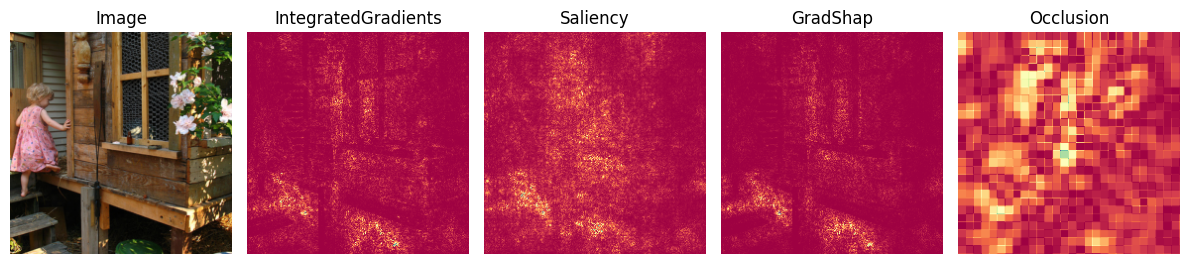

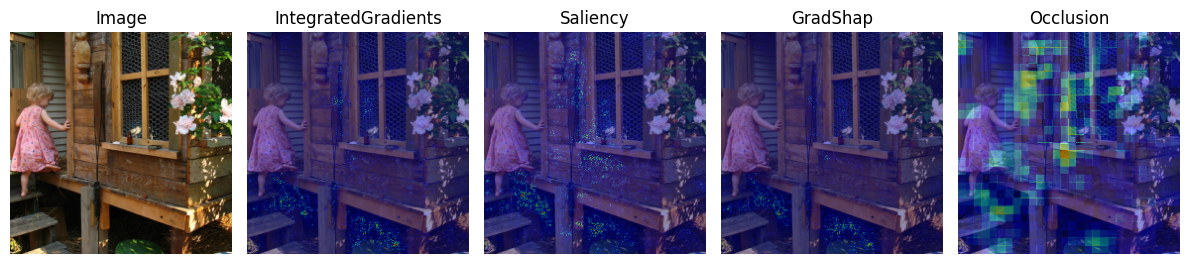

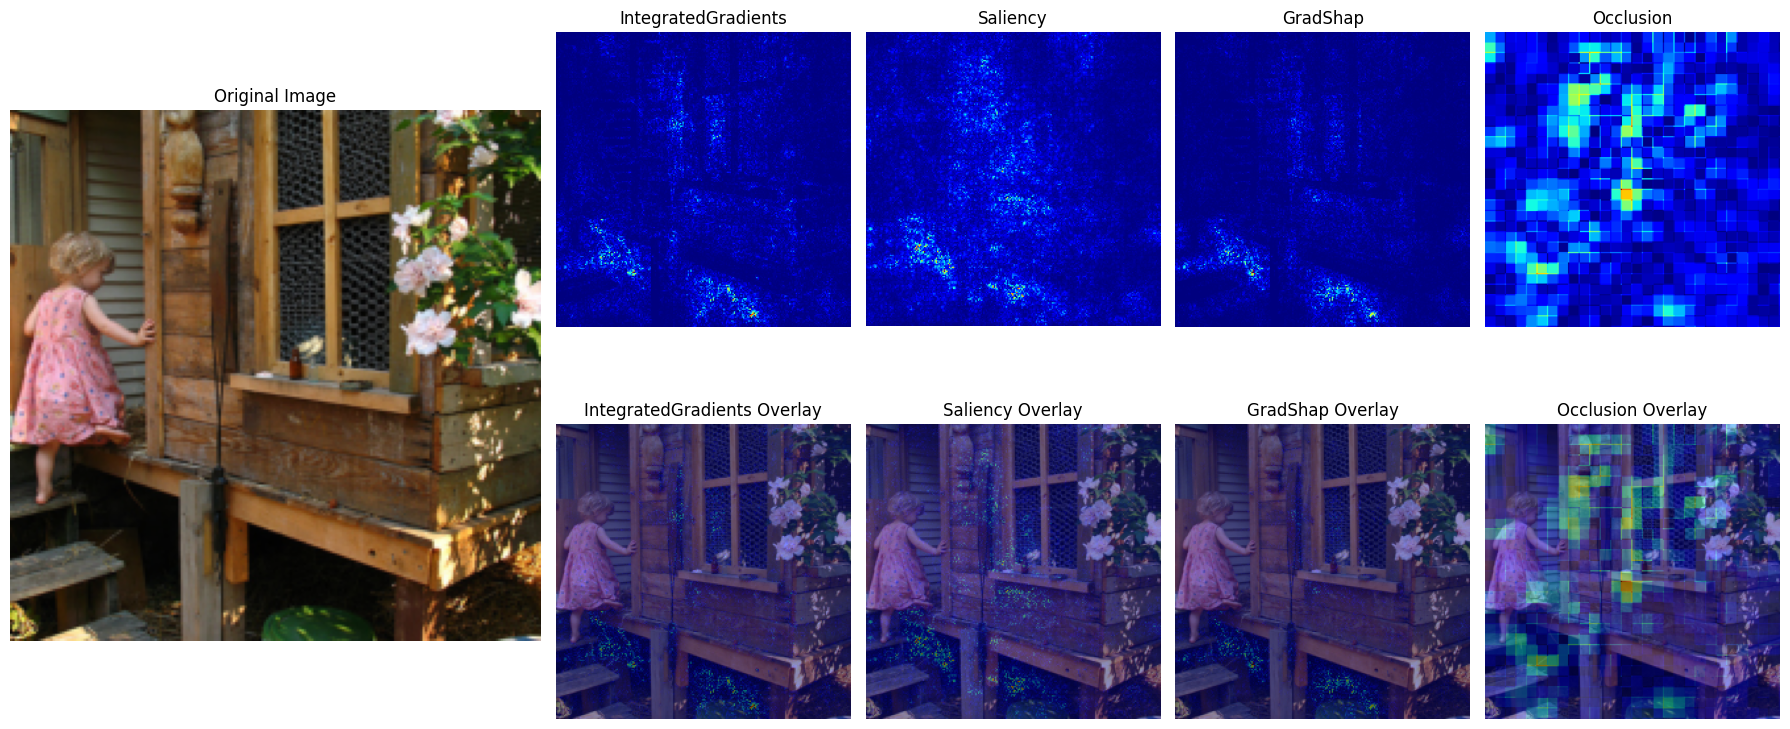

Loading weights:   0%|          | 0/177 [00:00<?, ?it/s]

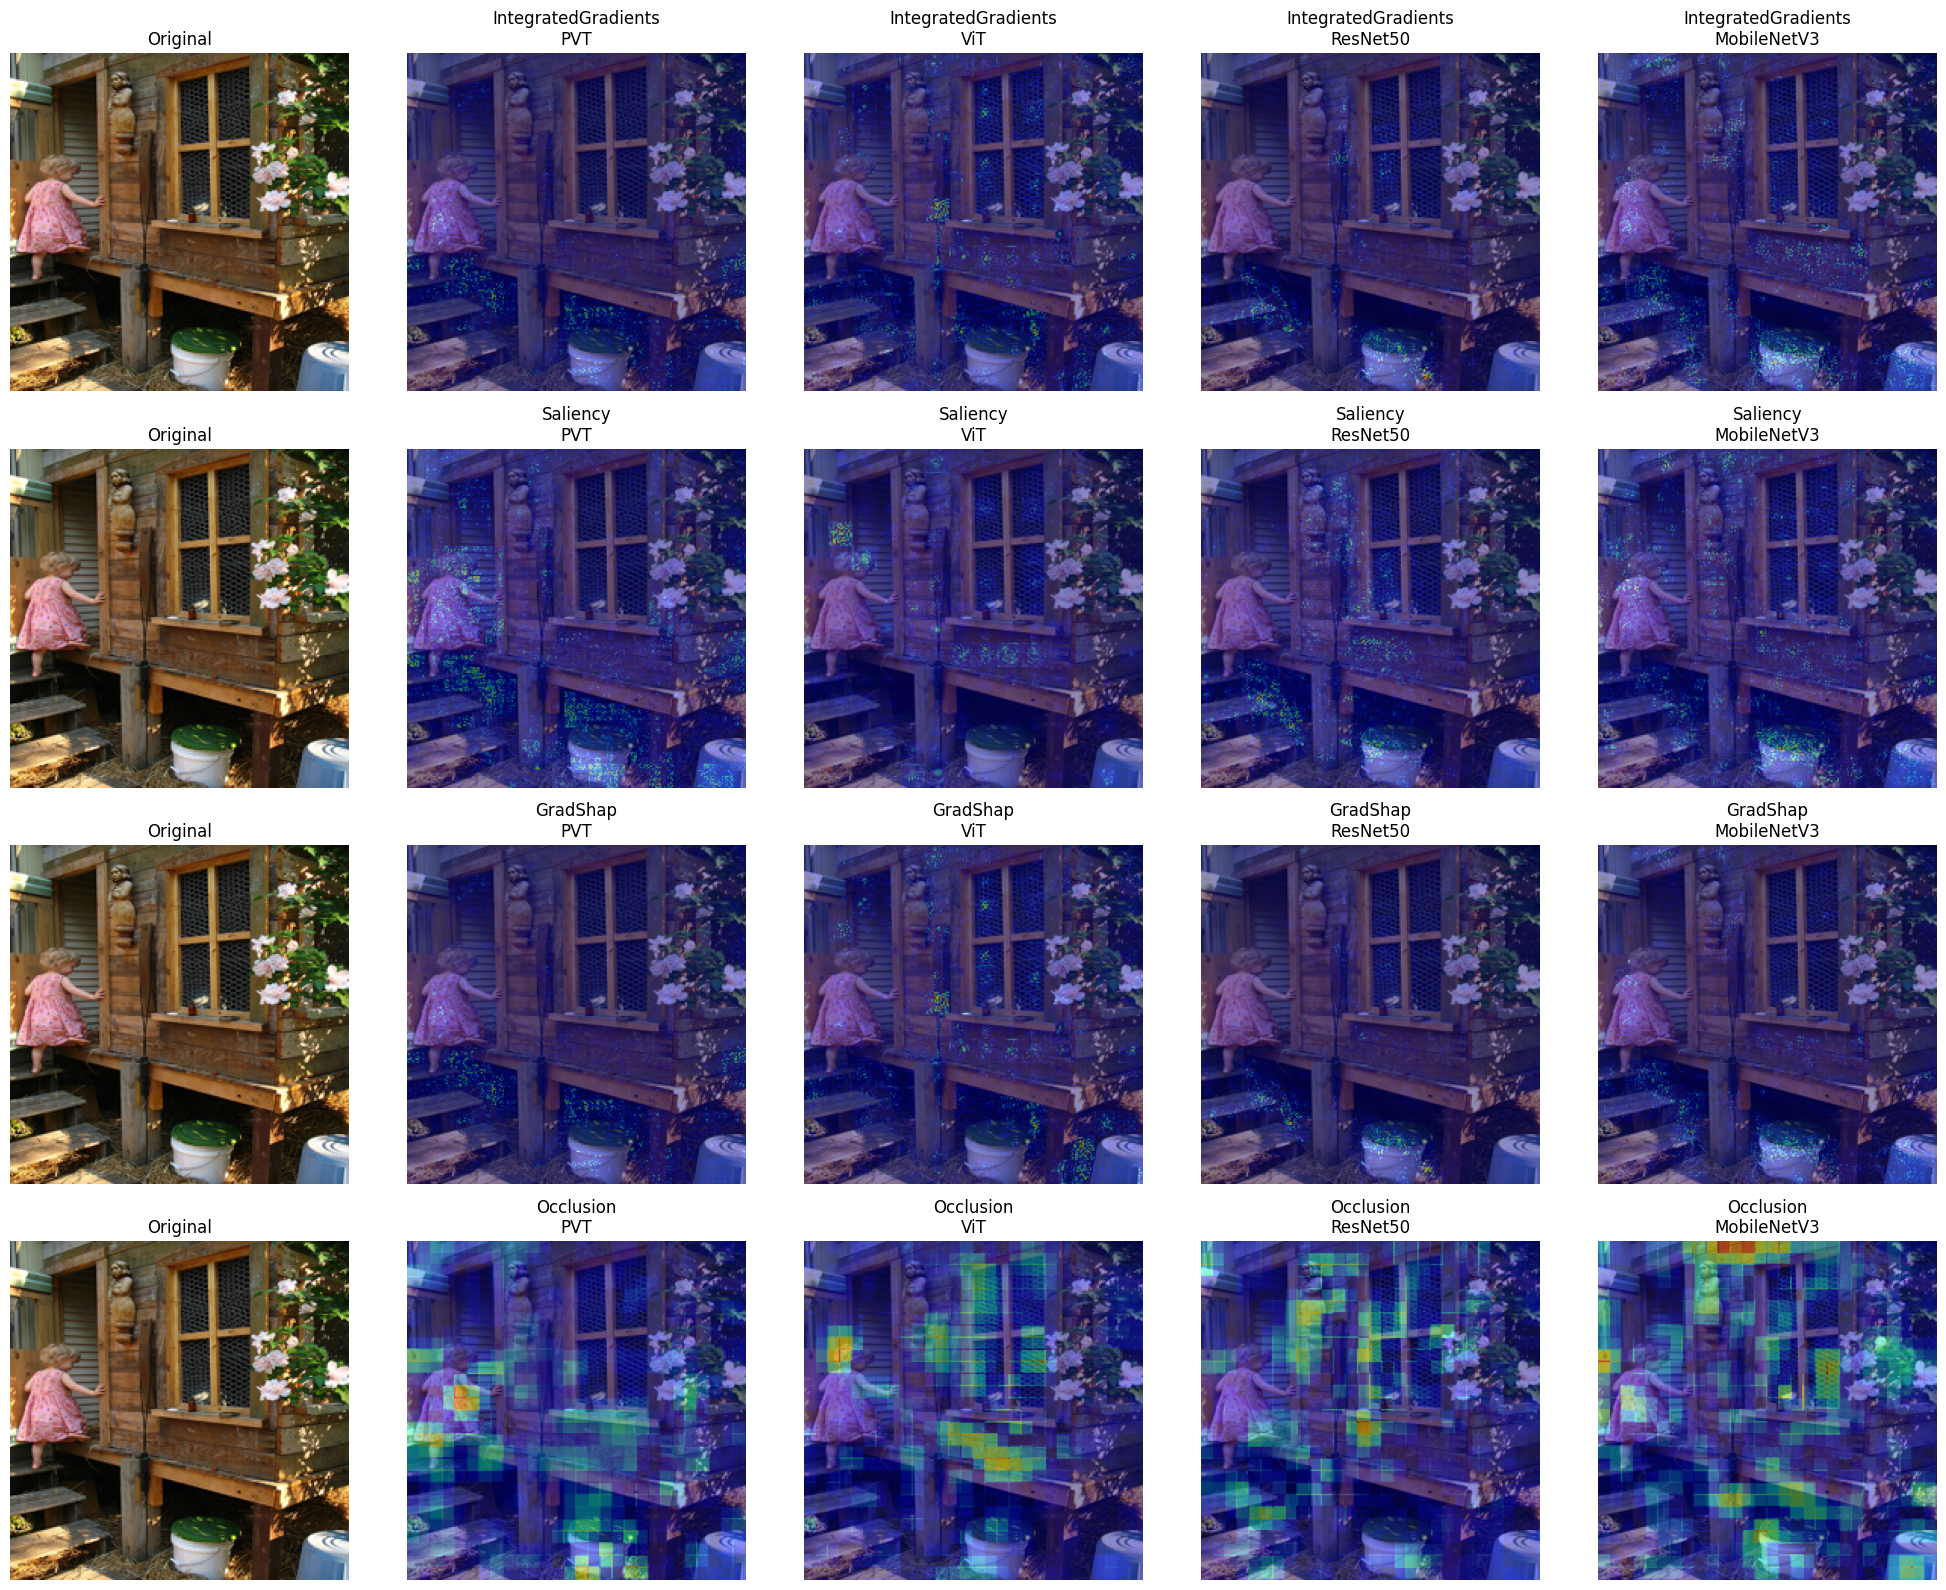

In [27]:
plot_attributions("resnet50", idx=0)
plot_attributions_overlay("resnet50", idx=0)
plot_attributions_and_overlay("resnet50", idx=0)
compare_models_side_by_side(idx = 0)

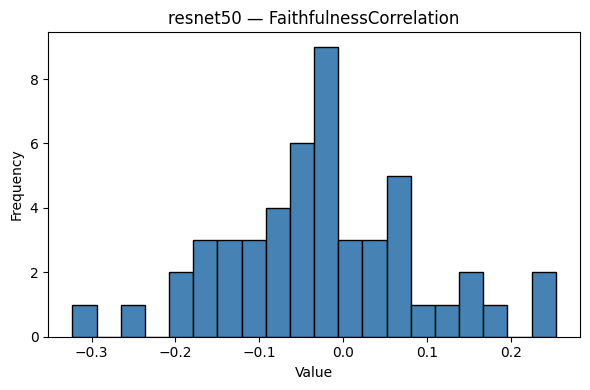

In [89]:
plot_metric_distribution("resnet50", "FaithfulnessCorrelation")


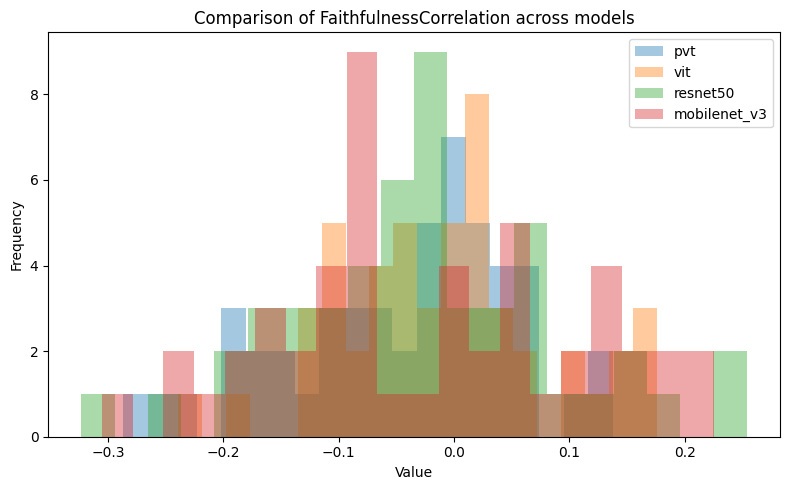

In [91]:
compare_metric_across_models("FaithfulnessCorrelation")


In [40]:
def load_captum_metrics(dataset_dir):
    rows = []

    for model_name in os.listdir(dataset_dir):
        pkl_path = os.path.join(dataset_dir, model_name, "captum_metrics.pkl")
        if not os.path.exists(pkl_path):
            continue

        with open(pkl_path, "rb") as f:
            records = pickle.load(f)

        # Convert list of dicts → DataFrame
        df = pd.DataFrame(records)

        # Compute mean of agreement metrics
        row = {
            "Model": model_name,
            "IG vs SAL": df["ig_sal"].mean(),
            "IG vs GS": df["ig_gs"].mean(),
            "IG vs OCC": df["ig_occ"].mean(),
            "SAL vs OCC": df["sal_occ"].mean(),
            "GS vs OCC": df["gs_occ"].mean(),
        }
        rows.append(row)

    return pd.DataFrame(rows)


In [45]:
dataset_dir = vision_xai_dir(CURRENT_DATASET, "pvt")  # your existing helper
df_agreement = load_captum_metrics(dataset_dir)
df_agreement

""


In [48]:
def find_dataset_root():
    # Find any captum_metrics.pkl in the project
    for root, dirs, files in os.walk(".", topdown=True):
        if "captum_metrics.pkl" in files:
            # root = .../<dataset>/<model_name>
            return os.path.dirname(root)  # go up one level
    raise RuntimeError("No captum_metrics.pkl found anywhere.")

dataset_root = find_dataset_root()
print("Dataset root:", dataset_root)

def load_captum_metrics(dataset_root):
    rows = []

    print("Scanning:", dataset_root)

    for model_name in os.listdir(dataset_root):
        model_dir = os.path.join(dataset_root, model_name)
        pkl_path = os.path.join(model_dir, "captum_metrics.pkl")

        # Skip non-directories
        if not os.path.isdir(model_dir):
            continue

        print("Checking:", pkl_path)

        if not os.path.exists(pkl_path):
            print("  → No pickle found.")
            continue

        print("  → Loading pickle.")

        with open(pkl_path, "rb") as f:
            records = pickle.load(f)

        df = pd.DataFrame(records)

        # Ensure expected columns exist
        required_cols = ["ig_sal", "ig_gs", "ig_occ", "sal_occ", "gs_occ"]
        if not all(col in df.columns for col in required_cols):
            print(f"  → Missing expected columns in {model_name}, skipping.")
            continue

        rows.append({
            "Model": model_name,
            "IG vs SAL": df["ig_sal"].mean(),
            "IG vs GS": df["ig_gs"].mean(),
            "IG vs OCC": df["ig_occ"].mean(),
            "SAL vs OCC": df["sal_occ"].mean(),
            "GS vs OCC": df["gs_occ"].mean(),
        })

    return pd.DataFrame(rows)


Dataset root: ./TFE_Data/Attributions/Vision/Flickr8k


In [49]:
df = load_captum_metrics(dataset_root)
print(df)


Scanning: ./TFE_Data/Attributions/Vision/Flickr8k
Checking: ./TFE_Data/Attributions/Vision/Flickr8k/pvt/captum_metrics.pkl
  → Loading pickle.
Checking: ./TFE_Data/Attributions/Vision/Flickr8k/vit/captum_metrics.pkl
  → Loading pickle.
Checking: ./TFE_Data/Attributions/Vision/Flickr8k/resnet50/captum_metrics.pkl
  → Loading pickle.
Checking: ./TFE_Data/Attributions/Vision/Flickr8k/mobilenet_v3/captum_metrics.pkl
  → Loading pickle.
          Model  IG vs SAL  IG vs GS  IG vs OCC  SAL vs OCC  GS vs OCC
0           pvt   0.419601  0.835574   0.106939    0.150841   0.104027
1           vit   0.164631  0.682919   0.059120    0.119470   0.059822
2      resnet50   0.354787  0.729687   0.203981    0.226880   0.185741
3  mobilenet_v3   0.371510  0.772231   0.131739    0.140578   0.130149
